In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [27]:
import pandas as pd
train = pd.read_pickle('/content/drive/MyDrive/Colab Notebooks/Future_ML_01/Data/train_features.pkl')

In [6]:
cutoff_date = train['date'].max() - pd.Timedelta(days = 90)
train_set = train[train['date'] < cutoff_date]
test_set = train[train['date'] >= cutoff_date]

print(train_set.shape, test_set.shape)

(2838726, 15) (162162, 15)


In [ ]:
# printing weekdays just to see what is there
date1 = train_set['date'].max()
date2 = test_set['date'].min()
print(date1.isoweekday())
print(date2.isoweekday())

2
3


In [ ]:
# checking if my sales_lag_7 data breaking or not on splitting
sample = train[(train['store_nbr']==1) & (train['family']=='AUTOMOTIVE')].sort_values('date')
sample[(sample['date'] >= cutoff_date - pd.Timedelta(days=3)) & (sample['date'] <= cutoff_date + pd.Timedelta(days=3))][['date','sales','sales_lag_7']]

,date,sales,sales_lag_7
2833380,2017-05-14,2.0,3.0
2835162,2017-05-15,9.0,5.0
2836944,2017-05-16,3.0,2.0
2838726,2017-05-17,2.0,2.0
2840508,2017-05-18,4.0,4.0
2842290,2017-05-19,5.0,4.0
2844072,2017-05-20,4.0,2.0


In [18]:
test_set = test_set.copy()
test_set['naive_pred'] = test_set['sales_lag_1']
#moving average baseline
test_set['ma_pred'] = test_set['rolling_mean_7']

In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# dropping un-necessary rows(with NaN's)
eval_set = test_set.dropna(subset = ['sales', 'naive_pred', 'ma_pred'])

# naive mse and mae
naive_mae = mean_absolute_error(eval_set['sales'], eval_set['naive_pred'])
naive_mse = np.sqrt(mean_squared_error(eval_set['sales'], eval_set['naive_pred']))

# moving average mse and mae
ma_mae = mean_absolute_error(eval_set['sales'], eval_set['ma_pred'])
ma_mse = np.sqrt(mean_squared_error(eval_set['sales'], eval_set['ma_pred']))

print("naive baseline: ", '\n', "rmse: ", naive_mse, "mae: ", naive_mae)
print("moving average baseline: ", '\n', "rmse: ", ma_mse, "mae: ", ma_mae)


naive baseline:  
 rmse:  469.31729743359404 mae:  128.10087739330484
moving average baseline:  
 rmse:  395.25144514484526 mae:  109.03250419366013


In [ ]:
train_set.to_pickle('/content/drive/MyDrive/Colab Notebooks/Future_ML_01/Data/train_set.pkl')
test_set.to_pickle('/content/drive/MyDrive/Colab Notebooks/Future_ML_01/Data/test_set.pkl')

In [ ]:
# next day
train_set = pd.read_pickle('/content/drive/MyDrive/Colab Notebooks/Future_ML_01/Data/train_set.pkl')
test_set = pd.read_pickle('/content/drive/MyDrive/Colab Notebooks/Future_ML_01/Data/test_set.pkl')
print(train_set.shape, test_set.shape)

(2838726, 15) (162162, 17)


In [ ]:
print(set(train_set.columns) - set(test_set.columns))
print(set(test_set.columns) - set(train_set.columns))

set()
{'naive_pred', 'ma_pred'}


In [ ]:
print(train_set.isnull().sum())

id                         0
date                       0
store_nbr                  0
family                     0
sales                      0
onpromotion                0
sales_lag_1             1782
sales_lag_7            12474
rolling_mean_7         12474
Month                      0
Year                       0
is_weekend                 0
launch_date            84429
is_launched                0
days_since_launched    84429
dtype: int64


In [10]:
# dropping those rows in these columns cause they are not very useful
train_model = train_set.dropna(subset = ['sales_lag_1', 'sales_lag_7', 'rolling_mean_7'])

# filling 0 on the place of nan values of days since launched cause its very useful info for model
train_model['days_since_launched']= train_model['days_since_launched'].fillna(0)

#dropping the whole columns as it contains only dates(not useful)
train_model = train_model.drop(columns=['launch_date'])

print(train_model.isnull().sum())
print(train_model.shape)

/tmp/ipykernel_841/755240245.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_model['days_since_launched']= train_model['days_since_launched'].fillna(0)


id                     0
date                   0
store_nbr              0
family                 0
sales                  0
onpromotion            0
sales_lag_1            0
sales_lag_7            0
rolling_mean_7         0
Month                  0
Year                   0
is_weekend             0
is_launched            0
days_since_launched    0
dtype: int64
(2826252, 14)


In [11]:
train_model = pd.get_dummies(train_model, columns = ['family'], drop_first=True)

feature_cols = ['sales_lag_1', 'sales_lag_7', 'rolling_mean_7', 'Month','Year', 'is_weekend','is_launched',
                           'days_since_launched'] + [columns for columns in train_model.columns if columns.startswith('family_') ]

In [12]:
feature_cols

['sales_lag_1',
 'sales_lag_7',
 'rolling_mean_7',
 'Month',
 'Year',
 'is_weekend',
 'is_launched',
 'days_since_launched',
 'family_BABY CARE',
 'family_BEAUTY',
 'family_BEVERAGES',
 'family_BOOKS',
 'family_BREAD/BAKERY',
 'family_CELEBRATION',
 'family_CLEANING',
 'family_DAIRY',
 'family_DELI',
 'family_EGGS',
 'family_FROZEN FOODS',
 'family_GROCERY I',
 'family_GROCERY II',
 'family_HARDWARE',
 'family_HOME AND KITCHEN I',
 'family_HOME AND KITCHEN II',
 'family_HOME APPLIANCES',
 'family_HOME CARE',
 'family_LADIESWEAR',
 'family_LAWN AND GARDEN',
 'family_LINGERIE',
 'family_LIQUOR,WINE,BEER',
 'family_MAGAZINES',
 'family_MEATS',
 'family_PERSONAL CARE',
 'family_PET SUPPLIES',
 'family_PLAYERS AND ELECTRONICS',
 'family_POULTRY',
 'family_PREPARED FOODS',
 'family_PRODUCE',
 'family_SCHOOL AND OFFICE SUPPLIES',
 'family_SEAFOOD']

In [13]:
from sklearn.linear_model import LinearRegression
x_train = train_model[feature_cols]
y_train = train_model['sales']

lr_model = LinearRegression()
lr_model.fit(x_train, y_train)

LinearRegression()

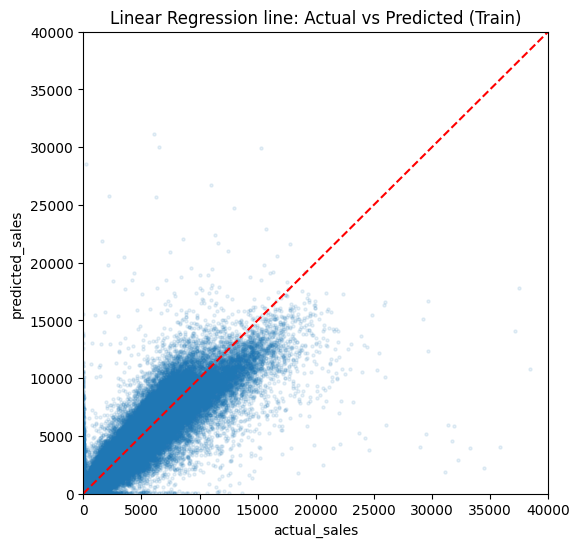

In [15]:
import matplotlib.pyplot as plt

y_train_pred = lr_model.predict(x_train)

plt.figure(figsize = (6,6))
plt.scatter(y_train, y_train_pred, alpha = 0.1,s=5)
plt.plot([0, 40000],[0,40000], color = 'red', linestyle = '--')
plt.xlim(0, 40000)
plt.ylim(0, 40000)
plt.xlabel('actual_sales')
plt.ylabel('predicted_sales')
plt.title('Linear Regression line: Actual vs Predicted (Train)')
plt.show()

In [ ]:
print((y_train_pred <0).sum())
print(y_train_pred.min())
print(r2_score(y_train, y_train_pred))

1042658
-35.90231441550054
0.9075993420922904


In [21]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=50,max_depth = 10, random_state=42)
rf_model.fit(x_train, y_train)

y_train_pred_rf = rf_model.predict(x_train)

In [ ]:
print((y_train_pred_rf <0).sum())
print(y_train_pred_rf.min())

0
0.0


In [22]:
def evaluate(label, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{label}--> MAE:{mae:.2f}, RMSE: {rmse:.2f}, R2: {r2:.4f}")

evaluate("for Linear Regression :", y_train,y_train_pred)
evaluate("for random forest regressor :", y_train,y_train_pred_rf)

for Linear Regression :--> MAE:83.39, RMSE: 330.84, R2: 0.9076
for random forest regressor :--> MAE:56.68, RMSE: 235.56, R2: 0.9532


In [23]:
test_model = test_set.dropna(subset = ['sales_lag_1', 'sales_lag_7', 'rolling_mean_7']).copy()
test_model['days_since_launched'] = test_model['days_since_launched'].fillna(0)
test_model = pd.get_dummies(test_model, columns = ['family'], drop_first=True)

# giving same index as it is in training data
test_model = test_model.reindex(columns = train_model.columns, fill_value=0)

x_test = test_model[feature_cols]
y_test = test_model['sales']

In [24]:
y_test_pred_lr = lr_model.predict(x_test)
y_test_pred_rf = rf_model.predict(x_test)

In [25]:
evaluate("for linear regression :", y_test, y_test_pred_lr)
evaluate("for random forest regressor :", y_test, y_test_pred_rf)

for linear regression :--> MAE:94.76, RMSE: 306.23, R2: 0.9469
for random forest regressor :--> MAE:74.99, RMSE: 273.90, R2: 0.9575


In [ ]:
import pickle

with open('/content/drive/MyDrive/Colab Notebooks/Future_ML_01/Data/rf_model.pkl', 'wb') as f:
  pickle.dump(rf_model, f)

with open('/content/drive/MyDrive/Colab Notebooks/Future_ML_01/Data/lr_model.pkl', 'wb') as f:
  pickle.dump(lr_model, f)

In [32]:
rf_beverages = (test_model['store_nbr'] == 1) & (test_model['family_BEVERAGES'] == 1)
y_test_rf_beverages = y_test[rf_beverages]
y_pred_rf_beverages = y_test_pred_rf[rf_beverages]
evaluate('random forest (store1 and beverages only)', y_test_rf_beverages, y_pred_rf_beverages)



random forest (store1 and beverages only)--> MAE:361.51, RMSE: 485.03, R2: 0.1932
